# Python 与 Jupyter 环境配置实操

这个 Notebook 用于一步步完成：
1. Python 与 pip 可用性检查
2. venv 创建与激活
3. 安装 Jupyter 与常用包
4. 注册并验证 Jupyter 内核
5. 在 VS Code 里绑定解释器与内核
6. 环境可用性验证与常见报错排查

建议在项目目录执行所有命令。

## 1) 检查本机 Python 与 pip
执行下面单元，确认 Python、pip 和解释器路径。Windows 常用 `where python`，Linux/macOS 常用 `which python`。

In [ ]:
import subprocess
import sys
import platform


def run_cmd(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"$ {cmd}")
    if result.stdout:
        print(result.stdout.strip())
    if result.stderr:
        print(result.stderr.strip())
    print("-" * 60)

run_cmd("python --version")
run_cmd("python -m pip --version")

if platform.system().lower().startswith("win"):
    run_cmd("where python")
else:
    run_cmd("which python")

print("当前内核解释器:", sys.executable)

## 2) 创建并激活项目虚拟环境（venv）
在终端中执行以下命令（按你的系统选择）。执行后可在下一单元验证 `sys.executable` 是否指向 `.venv`。

In [ ]:
import os
import sys
import platform

print("项目目录:", os.getcwd())
print("当前解释器:", sys.executable)
print("系统:", platform.platform())

print("\n请在终端执行:")
print("python -m venv .venv")
if platform.system().lower().startswith("win"):
    print(r".venv\Scripts\activate")
else:
    print("source .venv/bin/activate")

## 3) 安装 Jupyter、ipykernel 与常用基础包
在已激活的虚拟环境中执行：
- `python -m pip install --upgrade pip`
- `python -m pip install jupyterlab notebook ipykernel numpy pandas matplotlib`

下面单元可以在 Notebook 内查看安装结果。

In [ ]:
import subprocess

for pkg in ["jupyter", "notebook", "ipykernel", "numpy", "pandas", "matplotlib"]:
    cmd = f"python -m pip show {pkg}"
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode == 0:
        lines = [line for line in r.stdout.splitlines() if line.startswith(("Name:", "Version:", "Location:"))]
        print("\n".join(lines))
    else:
        print(f"未安装: {pkg}")
    print("-" * 60)

subprocess.run("python -m pip list", shell=True)

## 4) 将虚拟环境注册为 Jupyter 内核
执行注册命令后，用 `jupyter kernelspec list` 验证。这里示例内核名为 `py-env`。

In [ ]:
import subprocess

commands = [
    'python -m ipykernel install --user --name py-env --display-name "Python (py-env)"',
    'jupyter kernelspec list',
]

for cmd in commands:
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.stdout:
        print(r.stdout)
    if r.stderr:
        print(r.stderr)
    print("-" * 60)

## 5) 启动 Jupyter 并创建测试 Notebook
在终端执行：
- `jupyter lab` 或 `jupyter notebook`

在浏览器中新建 Notebook，选择 `Python (py-env)` 内核后运行一个最小测试（打印 Python 版本与包版本）。

## 6) 在 VS Code 中绑定解释器与 Notebook 内核
1. `Ctrl+Shift+P` 打开命令面板。
2. 执行 `Python: Select Interpreter`，选择项目中的 `.venv` 解释器。
3. 打开 `.ipynb` 后，在右上角 Kernel 位置选择 `Python (py-env)`。
4. 运行一个单元，确认输出与终端环境一致。

## 7) 用代码验证环境是否可用
下方代码会导入核心包，打印版本信息，并绘制简单曲线检查渲染链路。

Python: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
Executable: e:\vs code\jy\.venv\Scripts\python.exe
Platform: Windows-10-10.0.26200-SP0
NumPy: 2.4.3
Pandas: 3.0.1

样例数据:
          x    sin(x)
0  0.000000  0.000000
1  0.063467  0.063424
2  0.126933  0.126592
3  0.190400  0.189251
4  0.253866  0.251148


e:\vs code\jy\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28210 (\N{CJK UNIFIED IDEOGRAPH-6E32}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\vs code\jy\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26579 (\N{CJK UNIFIED IDEOGRAPH-67D3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\vs code\jy\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\vs code\jy\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


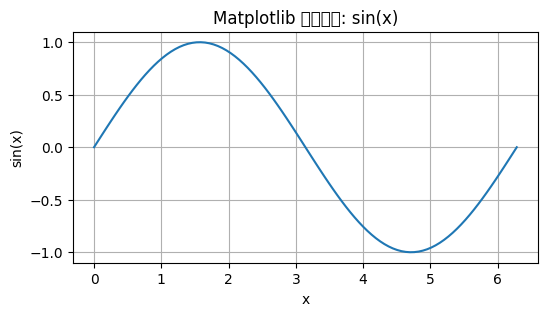

In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

df = pd.DataFrame({"x": x[:5], "sin(x)": y[:5]})
print("\n样例数据:")
print(df)

plt.figure(figsize=(6, 3))
plt.plot(x, y)
plt.title("Matplotlib 渲染测试: sin(x)")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

## 8) 常见报错的命令级排查
可直接执行以下命令定位“内核丢失/包装错环境”等问题：
- `python -m pip show ipykernel`
- `jupyter --paths`
- `jupyter troubleshoot`
- `jupyter kernelspec list`
- 重新注册：`python -m ipykernel install --user --name py-env --display-name "Python (py-env)"`

若有重复或错误 kernelspec，可删除异常目录后重新注册。

In [ ]:
import subprocess

diag_cmds = [
    "python -m pip show ipykernel",
    "jupyter --paths",
    "jupyter kernelspec list",
]

for cmd in diag_cmds:
    print(f"\n$ {cmd}")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(r.stdout if r.stdout else "(no stdout)")
    if r.stderr:
        print("[stderr]")
        print(r.stderr)